In [9]:
#Run in terminal
#%pip install medmnist
#%pip -m install dlordinal

In [10]:
#Packages
from medmnist import RetinaMNIST
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import DataLoader
import torch.nn as nn
from dlordinal.metrics import amae, mmae, accuracy_off1
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier


Dataset RetinaMNIST of size 28 (retinamnist)
    Number of datapoints: 1080
    Root location: C:\Users\tyenc\.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0


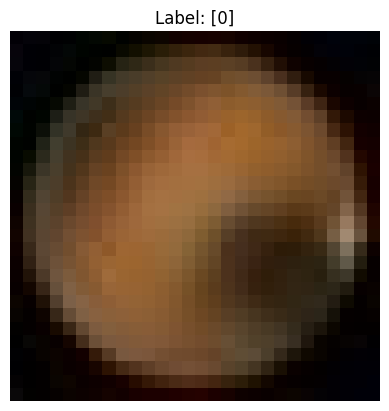


TRAIN split:
  Label 0: 486 images
  Label 1: 128 images
  Label 2: 206 images
  Label 3: 194 images
  Label 4: 66 images

VAL split:
  Label 0: 54 images
  Label 1: 12 images
  Label 2: 28 images
  Label 3: 20 images
  Label 4: 6 images

TEST split:
  Label 0: 174 images
  Label 1: 46 images
  Label 2: 92 images
  Label 3: 68 images
  Label 4: 20 images
total over train, val and test
Label 0: 714 images
Label 1: 186 images
Label 2: 326 images
Label 3: 282 images
Label 4: 92 images

Train set (1080 samples):
  Class 0: 486 (45.00%)
  Class 1: 128 (11.85%)
  Class 2: 206 (19.07%)
  Class 3: 194 (17.96%)
  Class 4: 66 (6.11%)

Val set (120 samples):
  Class 0: 54 (45.00%)
  Class 1: 12 (10.00%)
  Class 2: 28 (23.33%)
  Class 3: 20 (16.67%)
  Class 4: 6 (5.00%)

Test set (400 samples):
  Class 0: 174 (43.50%)
  Class 1: 46 (11.50%)
  Class 2: 92 (23.00%)
  Class 3: 68 (17.00%)
  Class 4: 20 (5.00%)


In [23]:
#Loading and preparing the data
train_data = RetinaMNIST(split="train", download=True)
val_data = RetinaMNIST(split="val", download=True)
test_data = RetinaMNIST(split="test", download=True)

train_data_raw = RetinaMNIST(split="train", download=True, size=224)
val_data_raw = RetinaMNIST(split="val", download=True, size=224)
test_data_raw = RetinaMNIST(split="test", download=True, size=224)

print(train_data) #There are 5 labels that classify increasing severity of diabetic retinopathy

#Example of an image
img, label = train_data[0]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Distribution of classifications in data. In each dataset, the distribution of classifications is similar.
splits = ["train", "val", "test"]
all_counts = {}
total_counts = Counter()
for split in splits:
    ds = RetinaMNIST(split=split, download=True)
    labels = [int(ds[i][1].item()) for i in range(len(ds))]
    all_counts[split] = Counter(labels)
    total_counts.update(labels)
for split in splits:
    print(f"\n{split.upper()} split:")
    for label, count in sorted(all_counts[split].items()):
        print(f"  Label {label}: {count} images")
print("total over train, val and test")
for label in sorted(total_counts.keys()):
    print(f"Label {label}: {total_counts[label]} images")

# Print the distribution of classes in the training set
train_class_counts = None # Added to use in the loss function during CNN model training

for split_name, dataset in [("Train", train_data_raw), ("Val", val_data_raw), ("Test", test_data_raw)]:
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    counts = np.bincount(labels)
    # Added to use in the loss function during CNN model training
    if split_name == "Train": 
        train_class_counts = torch.tensor(counts, dtype=torch.float)
    print(f"\n{split_name} set ({len(dataset)} samples):")
    for class_index, count in enumerate(counts):
        print(f"  Class {class_index}: {count} ({count / len(dataset) * 100:.2f}%)")

In [12]:
# Select all images from the training set 
all_images = np.stack([np.array(train_data[i][0]) for i in range(len(train_data))])

channel_names = ['R', 'G', 'B']
channel_means = []
channel_stds  = []

# Calculate mean and std for each channel
for c, name in enumerate(channel_names):
    ch = all_images[:, :, :, c]
    channel_means.append(ch.mean())
    channel_stds.append(ch.std())
    # print(f"Channel {name} — mean: {ch.mean():.3f}, std: {ch.std():.3f}")


mean = [channel_means[0]/255, channel_means[1]/255, channel_means[2]/255]
std  = [channel_stds[0]/255, channel_stds[1]/255, channel_stds[2]/255]

print(f"Channel means: {mean}")
print(f"Channel stds: {std}")

# converts image to tensor and scales to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),      
    transforms.Normalize(mean=mean, std=std)
])

# Apply the transformations to the datasets
train_data = RetinaMNIST(split='train', download=True, transform=transform)
val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

Channel means: [np.float64(0.39838941595156585), np.float64(0.24472671012849584), np.float64(0.15575321332236597)]
Channel stds: [np.float64(0.2982864611477896), np.float64(0.20048242021552953), np.float64(0.15065953323691267)]


C:\Users\tyenc\AppData\Local\Temp\ipykernel_23704\2395953904.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  images = np.stack([np.array(dataset[i][0]) for i in range(len(dataset))])


LR val accuracy: 0.4000
One-off accuracy: 0.6333
Average mean absolute error (AMAE): 1.1295
Maximum mean absolute error (MMAE): 1.7143
Quadratic weighted kappa: 0.4530

RF val accuracy: 0.4667
One-off accuracy: 0.8500
Average mean absolute error (AMAE): 0.9158
Maximum mean absolute error (MMAE): 1.5000
Quadratic weighted kappa: 0.6122

SVC val accuracy: 0.4583
One-off accuracy: 0.7250
Average mean absolute error (AMAE): 1.0864
Maximum mean absolute error (MMAE): 1.5000
Quadratic weighted kappa: 0.4835

KNN val accuracy: 0.5250
One-off accuracy: 0.7333
Average mean absolute error (AMAE): 1.1780
Maximum mean absolute error (MMAE): 2.0000
Quadratic weighted kappa: 0.3954



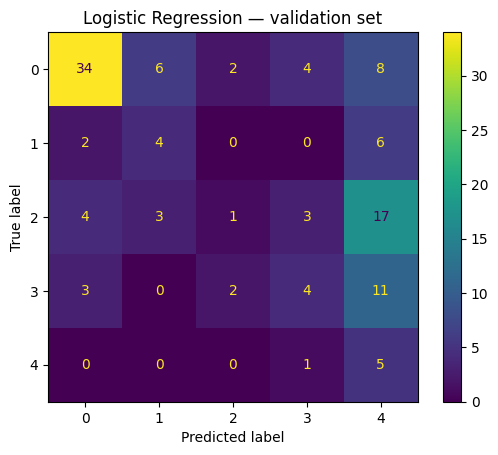

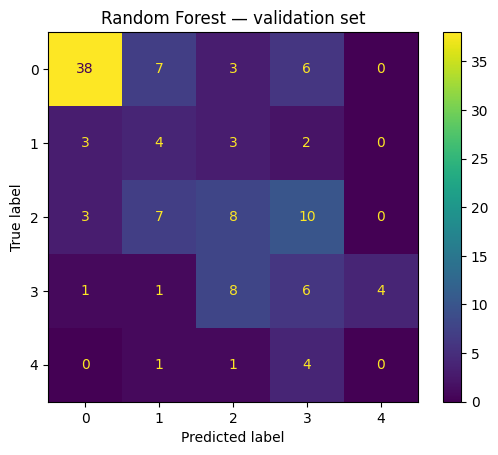

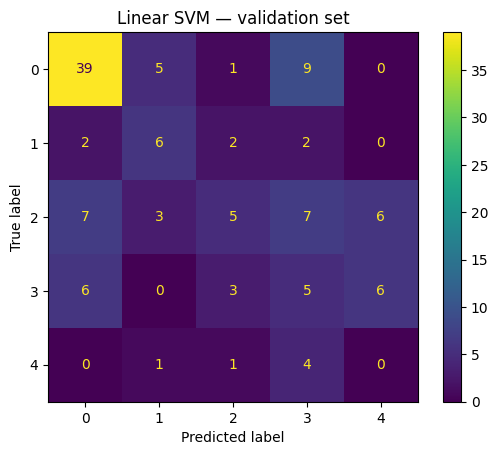

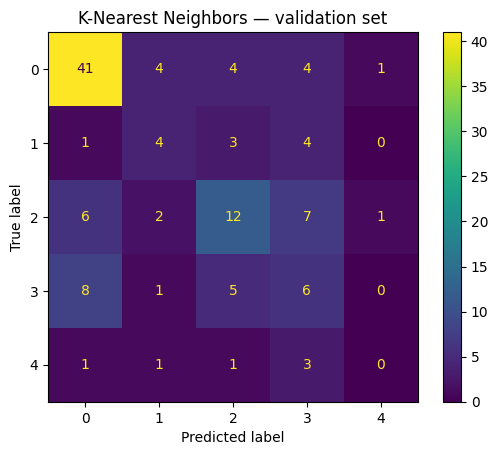

In [13]:
# Baseline model training

# Flatten the images, because sklearn models expects 1D feature vectors, not 2D images
def prepare_sklearn_data(dataset) :
    images = np.stack([np.array(dataset[i][0]) for i in range(len(dataset))])
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    # flatten each image from (3, 28, 28) to (2352)
    images = images.reshape(len(dataset), -1)
    # normalize to [0, 1]
    images = images / 255.0
    return images, labels



# Create new flat datasets with normalized pixel values
X_train, y_train = prepare_sklearn_data(train_data)
X_val,   y_val   = prepare_sklearn_data(val_data)
X_test,  y_test  = prepare_sklearn_data(test_data)

# Train a logistic regression model 
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
model.fit(X_train, y_train)

lr_val_preds = model.predict(X_val)
lr_val_acc = accuracy_score(y_val, lr_val_preds)
print(f"LR val accuracy: {lr_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, lr_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, lr_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, lr_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, lr_val_preds, weights='quadratic'):.4f}\n")


# Train a random forest model 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
print(f"RF val accuracy: {rf_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, rf_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, rf_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, rf_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, rf_val_preds, weights='quadratic'):.4f}\n")

# Train a linear SVM model 
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
best_C, best_svc_acc = None, -1.0  # initialize variables to assure first loop will score the lowest c value. next loop will always update because it will score higher than -1

# Find best performing Regularization parameter C for linear SVM model
for C in C_values:
    # Training model with various c values and saving the best
    svc = LinearSVC(C=C, max_iter=7000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
    svc.fit(X_train, y_train)
    acc = accuracy_score(y_val, svc.predict(X_val))
    if acc > best_svc_acc:
        best_svc_acc, best_C = acc, C

# print(f"Best C: {best_C}")

# Retrain with best C
svc_model = LinearSVC(C=best_C, max_iter=7000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
svc_model.fit(X_train, y_train)

svc_val_preds = svc_model.predict(X_val) 
svc_val_acc = accuracy_score(y_val, svc_val_preds)
print(f"SVC val accuracy: {svc_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, svc_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, svc_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, svc_val_preds):.4f}") 
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, svc_val_preds, weights='quadratic'):.4f}\n")

# Train a k-nearest neighbors model
k_values = [1, 3, 5, 7, 9, 11, 15]
best_k, best_knn_acc = None, -1.0 # initialize variables to assure first loop will score the lowest k value. next loop will always update because it will score higher than -1

# Find best performing k for k-nearest neighbors model
for k in k_values:
    # Training model with various k values and saving the best
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance') # weights='balanced' to handle class imbalance in the dataset
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    if acc > best_knn_acc:
        best_knn_acc, best_k = acc, k

# print(f"Best k: {best_k}")

#  Retrain with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_model.fit(X_train, y_train)

knn_val_preds = knn_model.predict(X_val)
knn_val_acc = accuracy_score(y_val, knn_val_preds)
print(f"KNN val accuracy: {knn_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, knn_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, knn_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, knn_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, knn_val_preds, weights='quadratic'):.4f}\n")

# Plot confusion matrix that displays the correct classification of samples predicted for each class (X) vs the true class labels (y)
cm = confusion_matrix(y_val, lr_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — validation set")
plt.show()

cm = confusion_matrix(y_val, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Random Forest — validation set")
plt.show()

cm = confusion_matrix(y_val, svc_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Linear SVM — validation set")
plt.show()

cm = confusion_matrix(y_val, knn_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("K-Nearest Neighbors — validation set")
plt.show()

Logistic Regression — test set
Accuracy: 0.3750
One-off accuracy: 0.6075
AMAE: 1.4029
MMAE: 1.7500
Quadratic weighted kappa: 0.3626

Random Forest — test set
Accuracy: 0.4825
One-off accuracy: 0.7800
AMAE: 1.1240
MMAE: 2.4000
Quadratic weighted kappa: 0.5274

Linear SVM — test set
Accuracy: 0.4725
One-off accuracy: 0.7400
AMAE: 1.2300
MMAE: 2.1500
Quadratic weighted kappa: 0.4784

KNN — test set
Accuracy: 0.4750
One-off accuracy: 0.7200
AMAE: 1.3374
MMAE: 2.7500
Quadratic weighted kappa: 0.4037



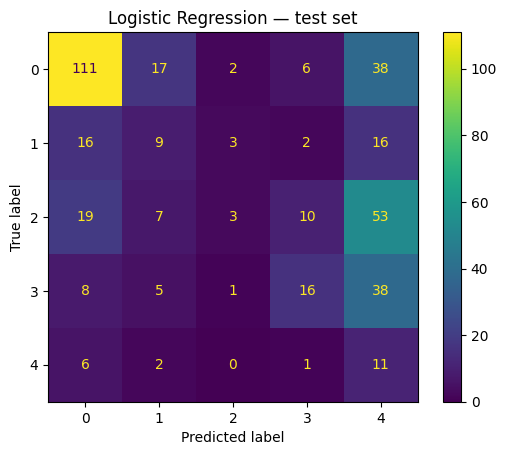

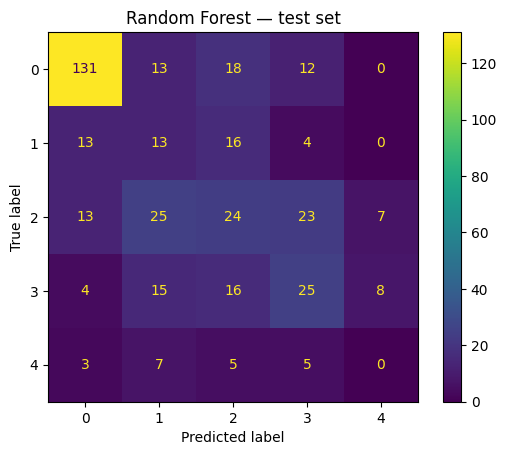

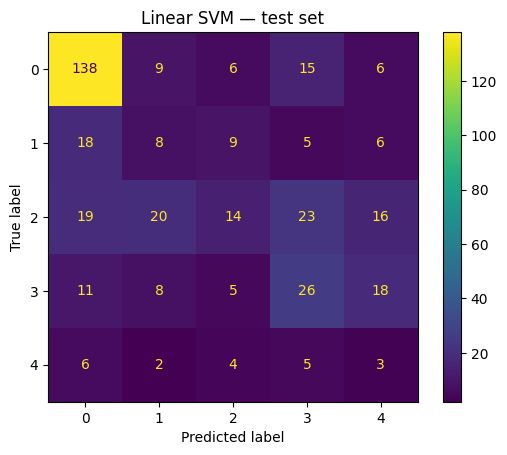

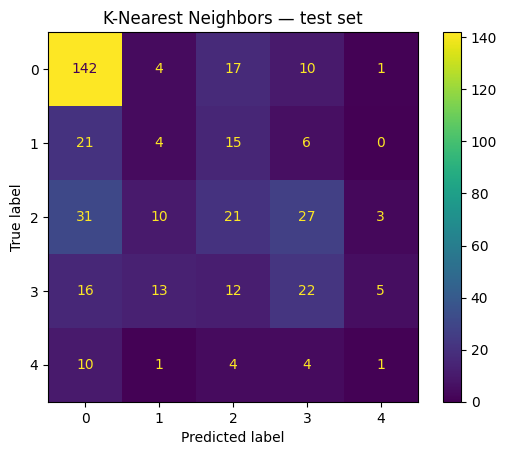

In [ ]:
# Evaluate all baseline models on the test set
lr_test_preds = model.predict(X_test)
print("Logistic Regression — test set")
print(f"Accuracy: {accuracy_score(y_test, lr_test_preds):.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, lr_test_preds):.4f}")
print(f"AMAE: {amae(y_test, lr_test_preds):.4f}")
print(f"MMAE: {mmae(y_test, lr_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, lr_test_preds, weights='quadratic'):.4f}\n")

rf_test_preds = rf_model.predict(X_test)
print("Random Forest — test set")
print(f"Accuracy: {accuracy_score(y_test, rf_test_preds):.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, rf_test_preds):.4f}")
print(f"AMAE: {amae(y_test, rf_test_preds):.4f}")
print(f"MMAE: {mmae(y_test, rf_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, rf_test_preds, weights='quadratic'):.4f}\n")

svc_test_preds = svc_model.predict(X_test)
print("Linear SVM — test set")
print(f"Accuracy: {accuracy_score(y_test, svc_test_preds):.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, svc_test_preds):.4f}")
print(f"AMAE: {amae(y_test, svc_test_preds):.4f}")
print(f"MMAE: {mmae(y_test, svc_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, svc_test_preds, weights='quadratic'):.4f}\n")

knn_test_preds = knn_model.predict(X_test)
print("KNN — test set")
print(f"Accuracy: {accuracy_score(y_test, knn_test_preds):.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, knn_test_preds):.4f}")
print(f"AMAE: {amae(y_test, knn_test_preds):.4f}")
print(f"MMAE: {mmae(y_test, knn_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, knn_test_preds, weights='quadratic'):.4f}\n")

# Confusion matrices for test set
cm = confusion_matrix(y_test, lr_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — test set")
plt.show()

cm = confusion_matrix(y_test, rf_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Random Forest — test set")
plt.show()

cm = confusion_matrix(y_test, svc_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Linear SVM — test set")
plt.show()

cm = confusion_matrix(y_test, knn_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("K-Nearest Neighbors — test set")
plt.show()


In [14]:
# return dataloaders for the RetinaMNIST dataset, given the mean and std for normalization and the batch size.
def get_dataloaders(mean, std, batch_size=32): #  feed 32 images at a time
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_data = RetinaMNIST(split='train', download=True, transform=transform)
    val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
    test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # shuffle the training data to help the model generalize better
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False) # no need to shuffle validation and test data, because we only evaluate the model on them, not train on them
    test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Wrap in Pytorch dataloader objects to enable batching and shuffling
train_loader, val_loader, test_loader = get_dataloaders(mean=mean, std=std)



In [ ]:
# Define CNN model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16*4*4,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,5)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*4*4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
val_preds  = []
val_all_labels = []

# Define loss function and optimizer (CHOICES)
weights = 1.0 / train_class_counts                # Inverse of class counts to give more weight to underrepresented classes
weights = weights / weights.sum()                 # normalise so they sum to 1
criterion = nn.CrossEntropyLoss(weight=weights)   # Assigns weights to the loss function to handle class imbalance in the dataset

optimizer = optim.Adam(net.parameters(), lr=0.001) # define optimizer with best learning rate found in test_optimizer.py 

# Model training
epochs = 20 # the amount of passes through the train_loader
min_validation_loss = np.inf # initialises a loss variable for validation loss

for e in range(epochs):
    #Instantiate running loss
    train_loss_epoch = 0.0
    net.train() #Puts model in training mode
    for i, data in enumerate(train_loader, 0):
        train_inputs, train_labels = data
        #Squeezes the image to 1D
        train_labels = train_labels.squeeze().long()
        #Clears the gradients
        optimizer.zero_grad()
        #Runs the forward pass
        train_outputs = net(train_inputs)
        #Finds the loss
        train_loss = criterion(train_outputs, train_labels)
        #Calculates gradients
        train_loss.backward()
        #Updates weights
        optimizer.step()
        #Sums all loss over the epoch and calculates an average loss per batch
        train_loss_epoch += train_loss.item()

    train_loss_epoch /= len(train_loader)
    
    #Model evaluation
    net.eval() # Puts model in evaluation mode
    validation_loss = 0.0 # Instantiates a validation loss
    #Turns off the gradient for evaluation
    with torch.no_grad():
        #For each batch, predict a label and calculate the loss
        for val_inputs, val_labels in val_loader:
            val_labels = val_labels.squeeze().long()
            val_outputs = net(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            #Sums all loss over the epoch and calculates an average loss per batch
            validation_loss += val_loss.item()
            _, predicted = torch.max(val_outputs, 1)

            val_preds.extend(predicted.numpy())
            val_all_labels.extend(val_labels.numpy())
    validation_loss /= len(val_loader)

    #Prints the average training and validation loss of the epoch
    # print(f'Epoch {e+1} Training Loss: {train_loss_epoch:.4f} Validation Loss: {validation_loss:.4f}')
    #Saves a model if its validation loss is lower than the currently lowest validation loss
    if min_validation_loss > validation_loss:
        print(f'Epoch {e+1} Training Loss: {train_loss_epoch:.4f} Validation Loss: {validation_loss:.4f}')
        print(f"Validation loss decreased from {min_validation_loss:.4f} to {validation_loss:.4f}. Saving the model")
        min_validation_loss = validation_loss
        torch.save(net.state_dict(), 'saved_model.pth')

        # Print validation metrics
        test_acc   = accuracy_score(val_all_labels, val_preds)
        test_qwk = cohen_kappa_score(val_all_labels, val_preds, weights='quadratic')
        test_off1   = accuracy_off1(val_all_labels, val_preds)
        test_amae   = amae(val_all_labels, val_preds)
        test_mmae   = mmae(val_all_labels, val_preds)

        print(f"Test accuracy:            {test_acc:.4f}")
        print(f"Quadratic weighted kappa: {test_qwk:.4f}")
        print(f"One-off accuracy:         {test_off1:.4f}")
        print(f"AMAE:                     {test_amae:.4f}")
        print(f"MMAE:                     {test_mmae:.4f}\n")

Epoch 1 Training Loss: 1.5672 Validation Loss: 1.5437
Validation loss decreased from inf to 1.5437. Saving the model
Test accuracy:            0.2750
Quadratic weighted kappa: 0.0913
One-off accuracy:         0.5417
AMAE:                     1.1630
MMAE:                     2.0000

Epoch 2 Training Loss: 1.5154 Validation Loss: 1.4242
Validation loss decreased from 1.5437 to 1.4242. Saving the model
Test accuracy:            0.3500
Quadratic weighted kappa: 0.3444
One-off accuracy:         0.5958
AMAE:                     1.1843
MMAE:                     1.4583

Epoch 3 Training Loss: 1.4700 Validation Loss: 1.3493
Validation loss decreased from 1.4242 to 1.3493. Saving the model
Test accuracy:            0.4000
Quadratic weighted kappa: 0.4110
One-off accuracy:         0.6222
AMAE:                     1.1399
MMAE:                     1.6389

Epoch 4 Training Loss: 1.4425 Validation Loss: 1.3350
Validation loss decreased from 1.3493 to 1.3350. Saving the model
Test accuracy:           

In [ ]:
# Print confusion matrix of the best CNN model for the validation set
net.load_state_dict(torch.load('saved_model.pth'))
net.eval()

val_preds_final = []
val_labels_final = []

with torch.no_grad():
    for val_inputs, val_labels in val_loader:
        val_labels = val_labels.squeeze().long()
        val_outputs = net(val_inputs)
        _, predicted = torch.max(val_outputs, 1)
        val_preds_final.extend(predicted.numpy())
        val_labels_final.extend(val_labels.numpy())

Test accuracy:            0.4975
Quadratic weighted kappa: 0.5716
One-off accuracy:         0.7775
AMAE:                     1.0124
MMAE:                     1.7000


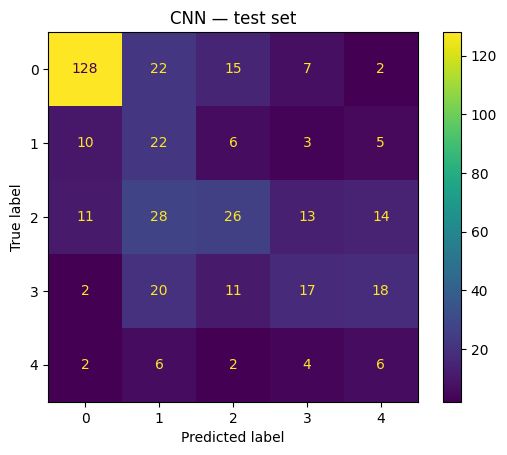

In [16]:
# Evaluation on the test set 

# Load the best saved model
best_model = net
best_model.load_state_dict(torch.load('saved_model.pth'))
best_model.eval()

all_preds  = []
all_labels = []

# turn off the gradient for evaluation, because we don't need to calculate gradients when evaluating the model, and it saves memory and makes it faster
with torch.no_grad():
    # loops through the test set in batches of 32 (set in get_dataloaders) 
    for test_inputs, test_labels in test_loader:
        #Squeezes the image to 1D
        test_labels = test_labels.squeeze().long()
        # Runs the images through the CNN. The output is a tensor of shape (batch_size, num_classes)
        test_outputs = best_model(test_inputs)
        # The predicted class is the one with the highest score. torch.max returns the maximum value and its index 
        _, predicted = torch.max(test_outputs, 1)
        # converting the bartch of predicted labels and true labels from PyTorch tensors to numpy arrays and adds them to the lists
        all_preds.extend(predicted.numpy())
        all_labels.extend(test_labels.numpy())
        # after this loop the lists all_preds and all_labels contain the predictions and true labels for all images in the test set

# Metrics
test_acc   = accuracy_score(all_labels, all_preds)
test_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
test_off1   = accuracy_off1(all_labels, all_preds)
test_amae   = amae(all_labels, all_preds)
test_mmae   = mmae(all_labels, all_preds)

print(f"Test accuracy:            {test_acc:.4f}")
print(f"Quadratic weighted kappa: {test_qwk:.4f}")
print(f"One-off accuracy:         {test_off1:.4f}")
print(f"AMAE:                     {test_amae:.4f}")
print(f"MMAE:                     {test_mmae:.4f}")

# Plots confusion matrix showing predicted labels (x-axis) against true labels (y-axis)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("CNN — test set")
plt.show()     